In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.522082,-3.222474,-0.091548,0.929147,1.395461,0
1,2.661620,-0.853059,0.135949,2.006228,-1.184854,0
2,-3.179365,0.651846,1.092192,-2.838384,1.264818,1
3,0.045879,-0.042313,0.667612,-0.309670,0.787194,1
4,-2.270132,0.497795,-0.057804,-2.022453,0.874475,1


In [4]:
# function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [6]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [7]:
df1 = sample_rows(df,0.1)

In [8]:
df2 = sample_rows(df,0.1)

In [9]:
df3 = sample_rows(df,0.1)

In [10]:
df3.shape

(10, 6)

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [14]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.33\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

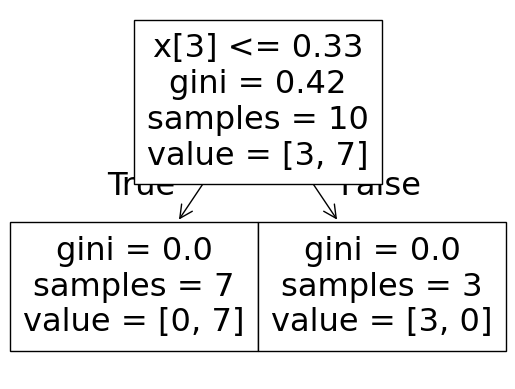

In [15]:
plot_tree(clf1)

[Text(0.4, 0.875, 'x[3] <= -0.558\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 0.825\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[3] <= -0.155\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]')]

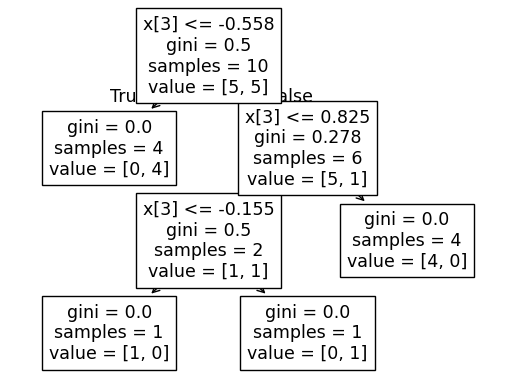

In [16]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[3] <= -0.642\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

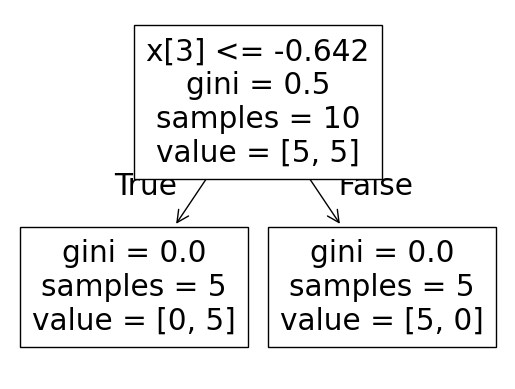

In [17]:
plot_tree(clf3)

In [18]:
sample_rows(df,0.1)

,col1,col2,col3,col4,col5,target
83,0.474097,0.462361,-2.613536,-0.247258,1.803274,0
40,0.320469,-0.379926,1.537415,-0.199581,0.373043,1
12,-1.190495,-5.151533,0.712540,-0.441442,1.525444,1
8,0.769728,-2.247522,-0.017551,2.251578,0.470350,0
95,-2.572133,-1.667303,3.306135,-2.123667,1.420596,1
20,0.515022,0.225878,-2.019341,-0.297498,0.839188,1
31,-0.548111,-2.645320,0.206840,3.487441,0.593343,0
66,0.531245,-0.165086,-2.370710,0.007167,1.460750,0
92,-3.579719,-2.954730,4.191244,-2.406663,1.438554,1
40,0.320469,-0.379926,1.537415,-0.199581,0.373043,1


In [19]:
clf1.predict(np.array([1.799801,	-0.133866,	3.313758,	3.436347,	-1.916879]).reshape(1,5))	

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [20]:
clf2.predict(np.array([1.799801,	-0.133866,	3.313758,	3.436347,	-1.916879]).reshape(1,5))	

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
clf3.predict(np.array([1.799801,	-0.133866,	3.313758,	3.436347,	-1.916879]).reshape(1,5))	

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
dfs1 = sample_features(df,0.8)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [23]:
dfs2 = sample_features(df,0.8)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [24]:
dfs3 = sample_features(df,0.8)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [25]:
print(dfs1.columns)
print(dfs2.columns)
print(dfs3.columns)

Index(['col2', 'col4', 'col1', 'col5', 'target'], dtype='object')
Index(['col4', 'col1', 'col3', 'col5', 'target'], dtype='object')
Index(['col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [26]:
dfs2

,col4,col1,col3,col5,target
0,0.929147,1.522082,-0.091548,1.395461,0
1,2.006228,2.661620,0.135949,-1.184854,0
2,-2.838384,-3.179365,1.092192,1.264818,1
3,-0.309670,0.045879,0.667612,0.787194,1
4,-2.022453,-2.270132,-0.057804,0.874475,1
...,...,...,...,...,...
95,-2.123667,-2.572133,3.306135,1.420596,1
96,1.894718,-0.265294,-1.231783,2.476780,0
97,-3.076958,-3.843867,5.052466,1.741774,1
98,2.341722,0.387283,-0.092019,0.879819,0


In [27]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [28]:
clf1.fit(dfs1.iloc[:,0:4],dfs1.iloc[:,-1])
clf2.fit(dfs2.iloc[:,0:4],dfs2.iloc[:,-1])
clf3.fit(dfs3.iloc[:,0:4],dfs3.iloc[:,-1])

DecisionTreeClassifier()

In [29]:
from sklearn.tree import plot_tree

[Text(0.4230769230769231, 0.9285714285714286, 'x[1] <= -0.111\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.7857142857142857, 'x[2] <= 0.08\ngini = 0.219\nsamples = 48\nvalue = [6, 42]'),
 Text(0.28846153846153844, 0.8571428571428572, 'True  '),
 Text(0.07692307692307693, 0.6428571428571429, 'gini = 0.0\nsamples = 38\nvalue = [0, 38]'),
 Text(0.23076923076923078, 0.6428571428571429, 'x[3] <= 1.219\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.15384615384615385, 0.5, 'x[0] <= -0.563\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.07692307692307693, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.23076923076923078, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.3076923076923077, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6923076923076923, 0.7857142857142857, 'x[1] <= 0.669\ngini = 0.26\nsamples = 52\nvalue = [44, 8]'),
 Text(0.5576923076923077, 0.8571428571428572, '  False'),
 Te

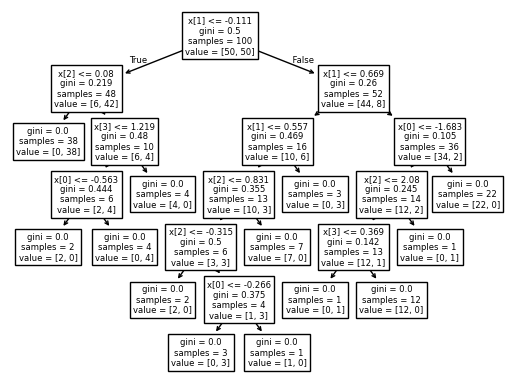

In [30]:
plot_tree(clf1)

[Text(0.4583333333333333, 0.9166666666666666, 'x[0] <= -0.111\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.75, 'x[2] <= -1.523\ngini = 0.219\nsamples = 48\nvalue = [6, 42]'),
 Text(0.3125, 0.8333333333333333, 'True  '),
 Text(0.1111111111111111, 0.5833333333333334, 'x[3] <= -0.889\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.05555555555555555, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[0] <= -0.348\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.2222222222222222, 0.25, 'x[0] <= -0.272\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.16666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2777777777777778, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 40\nvalue = [0, 40

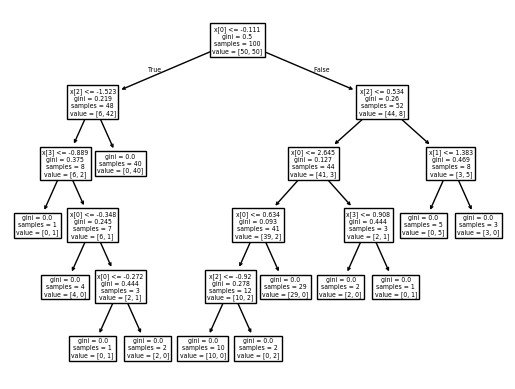

In [31]:
plot_tree(clf2)

[Text(0.4513888888888889, 0.9285714285714286, 'x[2] <= -0.111\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[1] <= -1.523\ngini = 0.219\nsamples = 48\nvalue = [6, 42]'),
 Text(0.3090277777777778, 0.8571428571428572, 'True  '),
 Text(0.1111111111111111, 0.6428571428571429, 'x[0] <= 0.203\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.05555555555555555, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.16666666666666666, 0.5, 'x[1] <= -2.316\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2222222222222222, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2222222222222222, 0.6428571428571429, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.7361111111111112, 0.7857142857142857, 'x[1] <= 0.534\ngini = 0.26\nsamples = 52\nvalue = [44, 8]'),
 Text(0.59375, 0.8571428571428572, '  False'),
 Text(0.58333333

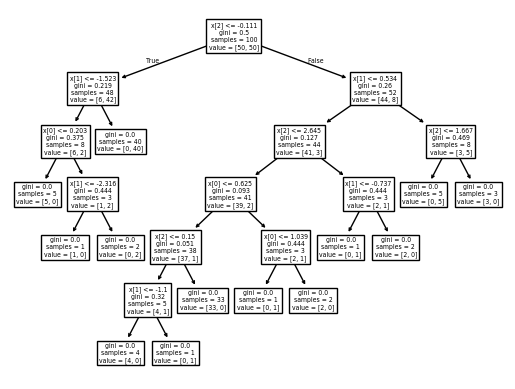

In [32]:
plot_tree(clf3)

In [33]:
clf1.predict(np.array([0.221399,	-0.717098,	-0.214088,	-1.124898]).reshape(1,4))	

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
clf2.predict(np.array([0.221399,	-0.717098,	-0.214088,	-1.124898]).reshape(1,4))	

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [35]:
clf3.predict(np.array([0.221399,	-0.717098,	-0.214088,	-1.124898]).reshape(1,4))

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [37]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [38]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\skjha\AppData\Local\Temp\ipykernel_6228\73133977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [39]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col4', 'target'], dtype='object')
Index(['col1', 'col3', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')


In [40]:
df3

,col2,col4,target
33,-3.570343,0.802736,0
33,-3.570343,0.802736,0
68,-0.183571,0.670189,0
80,1.474987,-0.771492,1
86,-2.008926,-1.769891,1
86,-2.008926,-1.769891,1
17,0.778862,0.598500,1
42,-2.133790,0.140274,1
6,1.422498,-0.226684,1
49,-3.911705,-1.965592,1


In [41]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [42]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [43]:
from sklearn.tree import plot_tree

[Text(0.5555555555555556, 0.9, 'x[1] <= 0.32\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.3333333333333333, 0.7, 'x[0] <= 0.529\ngini = 0.213\nsamples = 33\nvalue = [4, 29]'),
 Text(0.4444444444444444, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[0] <= 0.397\ngini = 0.064\nsamples = 30\nvalue = [1, 29]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 25\nvalue = [0, 25]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= 0.495\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4444444444444444, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7777777777777778, 0.7, 'x[1] <= 2.6\ngini = 0.111\nsamples = 17\nvalue = [16, 1]'),
 Text(0.6666666666666667, 0.8, '  False'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.8888888888888888, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'

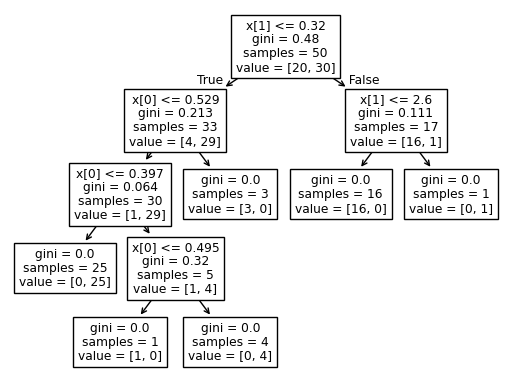

In [44]:
plot_tree(clf1)

[Text(0.5, 0.9285714285714286, 'x[0] <= -0.925\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.4090909090909091, 0.7857142857142857, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.4545454545454546, 0.8571428571428572, 'True  '),
 Text(0.5909090909090909, 0.7857142857142857, 'x[1] <= 0.602\ngini = 0.32\nsamples = 30\nvalue = [24, 6]'),
 Text(0.5454545454545454, 0.8571428571428572, '  False'),
 Text(0.36363636363636365, 0.6428571428571429, 'x[1] <= -0.277\ngini = 0.204\nsamples = 26\nvalue = [23, 3]'),
 Text(0.18181818181818182, 0.5, 'x[0] <= 2.632\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.09090909090909091, 0.35714285714285715, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.2727272727272727, 0.35714285714285715, 'x[1] <= -1.002\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.18181818181818182, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]

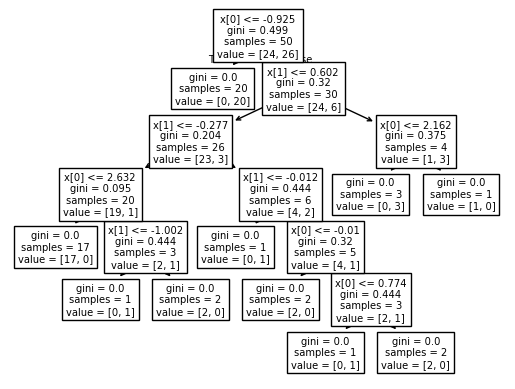

In [45]:
plot_tree(clf2)

[Text(0.5416666666666666, 0.9, 'x[1] <= 0.325\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3333333333333333, 0.7, 'x[1] <= -0.265\ngini = 0.204\nsamples = 26\nvalue = [3, 23]'),
 Text(0.4375, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[0] <= 0.109\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(0.08333333333333333, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.25, 0.3, 'x[0] <= 0.545\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.5, 0.5, 'x[1] <= -0.237\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.4166666666666667, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5833333333333334, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.75, 0.7, 'x[0] <= 0.555\ngini = 0.153\nsamples = 24\nvalue = [22, 2]'),
 Text(0.6458333333333333, 0.8, '  False'),
 Text(0.6666666666666666, 0.5

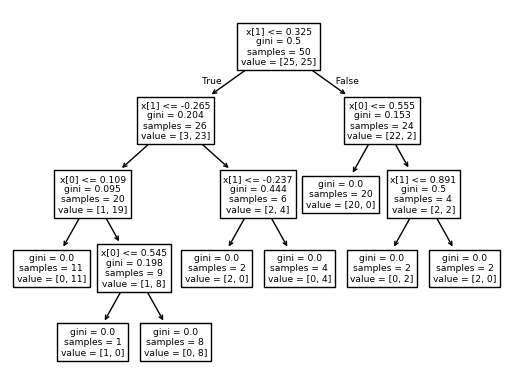

In [46]:
plot_tree(clf3)

In [47]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [48]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [49]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\skjha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])